<a href="https://colab.research.google.com/github/douglasbaquiao/materials-solar-ml/blob/main/notebooks/v2_eda_campos_expandidos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Materials Informatics — EDA v2
## Double Perovskites Halogenadas × Kesteritas para Aplicações Fotovoltaicas

**Versão:** 2.0  
**Diferenças em relação à v1:**
- Extração e feature engineering delegadas ao módulo `src/extraction.py`
- Campos expandidos: `efermi`, `weighted_work_function`, `n_refractive`, `e_total`, `possible_species`, `theoretical`, `has_props`, `database_IDs`
- Dados salvos em `data/processed/` e figuras em `figures/`
- Compatível com execução local e Google Colab

---
> **Como usar:** execute as células em ordem. Na primeira execução, a **Célula 3**
> faz a extração via API e salva os CSVs. Nas execuções seguintes, comente o
> `pipeline_completo()` e descomente o `carregar()` para evitar re-extrair da API.

## 1. Configuração do Ambiente

Instala dependências e configura a chave de API.  
O bloco de detecção de ambiente (Colab vs. local) garante que o notebook
funcione sem modificação nos dois contextos.

In [ ]:
# ── Dependências ─────────────────────────────────────────────────────────────
# Colab já tem pandas/numpy/matplotlib — instalamos apenas o que falta
import subprocess, sys
subprocess.run([
    sys.executable, "-m", "pip", "install",
    "mp-api", "pymatgen", "python-dotenv", "-q"
])

# ── Detecção de ambiente ──────────────────────────────────────────────────────
import os

try:
    from google.colab import userdata
    EM_COLAB = True
except ImportError:
    EM_COLAB = False

print(f"Ambiente: {'Google Colab' if EM_COLAB else 'Local (Jupyter / VS Code)'}")

Ambiente: Google Colab


### 1.1 Chave de API

- **Colab:** lida automaticamente do painel *Secrets* (🔑 na barra lateral).  
  Configure uma entrada com o nome `MP_API_KEY` antes de executar.
- **Local:** lida do arquivo `.env` na raiz do projeto ou da variável de ambiente.  
  O `.env` está no `.gitignore` e nunca é versionado.

In [ ]:
if EM_COLAB:
    # Injeta o secret como variável de ambiente para que extraction.py
    # o leia normalmente via os.environ — sem modificar o módulo
    os.environ["MP_API_KEY"] = userdata.get("MP_API_KEY")
    print("Chave carregada via Colab Secrets.")
else:
    # Localmente, python-dotenv carrega o .env automaticamente dentro de conectar_api()
    print("Chave será lida do .env ou da variável de ambiente MP_API_KEY.")

Chave carregada via Colab Secrets.


## 2. Estrutura de Pastas do Repositório

Criamos as pastas necessárias caso ainda não existam.  
No Colab, o repositório é clonado em `/content/materials-solar-ml/`;  
localmente, o notebook é executado a partir da raiz do repositório.

```
materials-solar-ml/
├── src/
│   └── extraction.py       ← módulo importado por este notebook
├── notebooks/
│   └── v2_eda_campos_expandidos.ipynb   ← este arquivo
├── data/
│   ├── raw/                ← no .gitignore
│   └── processed/          ← CSVs gerados aqui
└── figures/                ← PNGs gerados aqui
```

In [ ]:
# ── Clone do repositório no Colab ────────────────────────────────────────────
REPO_URL  = "https://github.com/douglasbaquiao/materials-solar-ml.git"  # ← ajustar
REPO_NAME = "materials-solar-ml"

if EM_COLAB:
    repo_path = f"/content/{REPO_NAME}"
    if not os.path.exists(repo_path):
        subprocess.run(["git", "clone", REPO_URL, repo_path])
        print(f"Repositório clonado em {repo_path}")
    else:
        # Atualiza para pegar eventuais mudanças no extraction.py
        subprocess.run(["git", "-C", repo_path, "pull"])
        print(f"Repositório atualizado: {repo_path}")
    os.chdir(repo_path)

# ── Raiz do repositório (funciona em Colab e local) ──────────────────────────
RAIZ = os.getcwd()
print(f"Raiz do projeto: {RAIZ}")

# ── Pastas de dados e figuras ─────────────────────────────────────────────────
PASTA_RAW       = os.path.join(RAIZ, "data", "raw")
PASTA_PROCESSED = os.path.join(RAIZ, "data", "processed")
PASTA_FIGURES   = os.path.join(RAIZ, "figures")

for pasta in [PASTA_RAW, PASTA_PROCESSED, PASTA_FIGURES]:
    os.makedirs(pasta, exist_ok=True)

print("Pastas verificadas:")
for p in [PASTA_RAW, PASTA_PROCESSED, PASTA_FIGURES]:
    print(f"  {p}")

Repositório atualizado: /content/materials-solar-ml
Raiz do projeto: /content/materials-solar-ml
Pastas verificadas:
  /content/materials-solar-ml/data/raw
  /content/materials-solar-ml/data/processed
  /content/materials-solar-ml/figures


## 3. Imports

O `extraction.py` é importado de `src/` — ele centraliza toda a lógica de
extração, limpeza e feature engineering. As constantes físicas do projeto
(`PV_GAP_MIN`, `IBSC_GAP_MAX`, etc.) também vêm de lá, garantindo
consistência com outros notebooks.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Adiciona src/ ao path para importar extraction.py
sys.path.insert(0, os.path.join(RAIZ, "src"))

from extraction import (
    conectar_api,
    extrair_familia,
    adicionar_features,
    pipeline_completo,
    exportar,
    carregar,
    # Constantes físicas — importadas para uso nos plots
    PV_GAP_MIN,
    PV_GAP_MAX,
    IBSC_GAP_MAX,
    HULL_THRESH,
    FAMILIAS,
)

# ── Configuração global de plots ──────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":       130,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        11,
})

CORES = {
    "perovskita": "#E07B54",
    "kesterita":  "#4A90D9",
}

print("Imports concluídos.")
print(f"Janela PV:   {PV_GAP_MIN}–{PV_GAP_MAX} eV")
print(f"Janela IBSC: {PV_GAP_MAX}–{IBSC_GAP_MAX} eV")
print(f"Hull thresh: {HULL_THRESH} eV/átomo")

Imports concluídos.
Janela PV:   1.0–1.8 eV
Janela IBSC: 1.8–2.6 eV
Hull thresh: 0.05 eV/átomo


## 4. Extração de Dados

**Primeira execução:** descomente `pipeline_completo()` — extrai da API e
salva os CSVs em `data/processed/`. Pode levar alguns minutos.

**Execuções seguintes:** mantenha apenas os `carregar()` — lê do disco
em segundos sem consumir cota da API.

> Os campos extraídos aqui são os da **lista v2** definida em `extraction.py`:  
> inclui `efermi`, `weighted_work_function`, `n_refractive`, `e_total`,  
> `possible_species`, `theoretical`, `has_props` e `database_IDs`.

In [ ]:

# ── OPÇÃO A: primeira execução — extrai da API e salva CSVs ──────────────────

dados = pipeline_completo(exportar_=True, verbose=True)
df_p  = dados["perovskita"]
df_k  = dados["kesterita"]

# ── OPÇÃO B: execuções seguintes — carrega do disco ───────────────────────────
df_p = carregar("perovskita", pasta=PASTA_PROCESSED)
df_k = carregar("kesterita",  pasta=PASTA_PROCESSED)

print(f"\nDouble Perovskitas: {len(df_p):>5} materiais, {len(df_p.columns)} colunas")
print(f"Kesteritas:         {len(df_k):>5} materiais, {len(df_k.columns)} colunas")


────────────────────────────────────────────────────────────
Extraindo: Double Perovskites Halogenadas (A2B'B''X6)
────────────────────────────────────────────────────────────


Retrieving SummaryDoc documents:   0%|          | 0/3899 [00:00<?, ?it/s]

  [F]  3899 documentos


Retrieving SummaryDoc documents:   0%|          | 0/1937 [00:00<?, ?it/s]

  [Cl]  1937 documentos


...

  [I]   875 documentos
  Total bruto: 7665
  Após filtro nsites≤40: 6171
  Duplicatas removidas: 138
  ✓ Final: 6033 materiais

  Exportado: data/processed/perovskita.csv  (6033 linhas, 47 colunas)

────────────────────────────────────────────────────────────
Extraindo: Kesteritas e Quaternários A2BCX4
────────────────────────────────────────────────────────────


Retrieving SummaryDoc documents:   0%|          | 0/3706 [00:00<?, ?it/s]

  [S]  3706 documentos


Retrieving SummaryDoc documents:   0%|          | 0/1870 [00:00<?, ?it/s]

  [Se]  1870 documentos
  Total bruto: 5576
  Após filtro nsites≤50: 4619
  Duplicatas removidas: 252
  ✓ Final: 4367 materiais

  Exportado: data/processed/kesterita.csv  (4367 linhas, 47 colunas)

Pipeline concluído:
  perovskita     :  6033 materiais  |  PV: 1052  |  IBSC:  905  |  Estáveis:  955
  kesterita      :  4367 materiais  |  PV:  720  |  IBSC:  511  |  Estáveis: 1134
  Carregado: /content/materials-solar-ml/data/processed/perovskita.csv  (6033 linhas, 47 colunas)
  Carregado: /content/materials-solar-ml/data/processed/kesterita.csv  (4367 linhas, 47 colunas)

Double Perovskitas:  6033 materiais, 47 colunas
Kesteritas:          4367 materiais, 47 colunas


## 5. Inspeção dos Campos v2

Antes de partir para a EDA, verificamos a cobertura dos campos novos —  
nem todos os materiais têm dados dielétricos, elásticos ou de superfície.  
Isso é esperado: o Materials Project calcula essas propriedades para  
subconjuntos específicos, não para toda a base.

As flags `has_dielectric_data`, `has_elastic_data` e `has_experimental_ref`  
criadas pelo `adicionar_features()` já encapsulam essa verificação.

In [ ]:
def cobertura_campos(df, nome):
    """Mostra a fração de valores não-nulos para os campos v2."""
    campos_v2 = [
        "efermi", "e_electronic", "e_ionic", "e_total", "n_refractive",
        "weighted_work_function", "weighted_surface_energy",
        "bulk_modulus_vrh", "shear_modulus_vrh", "universal_anisotropy",
        "has_dielectric_data", "has_elastic_data", "has_experimental_ref",
    ]
    print(f"\n── Cobertura de campos v2: {nome} (n={len(df)}) ──")
    for campo in campos_v2:
        if campo not in df.columns:
            print(f"  {campo:<35} ausente no DataFrame")
            continue
        if df[campo].dtype == bool or df[campo].dtype == object:
            n = df[campo].sum() if df[campo].dtype == bool else df[campo].notna().sum()
        else:
            n = df[campo].notna().sum()
        pct = 100 * n / len(df)
        barra = "█" * int(pct / 5) + "░" * (20 - int(pct / 5))
        print(f"  {campo:<35} {barra}  {n:>5} / {len(df)} ({pct:5.1f}%)")

cobertura_campos(df_p, "Double Perovskitas")
cobertura_campos(df_k, "Kesteritas")


── Cobertura de campos v2: Double Perovskitas (n=6033) ──
  efermi                              ████████████████████   6033 / 6033 (100.0%)
  e_electronic                        ░░░░░░░░░░░░░░░░░░░░    280 / 6033 (  4.6%)
  e_ionic                             ░░░░░░░░░░░░░░░░░░░░    280 / 6033 (  4.6%)
  e_total                             ░░░░░░░░░░░░░░░░░░░░    280 / 6033 (  4.6%)
  n_refractive                        ░░░░░░░░░░░░░░░░░░░░    280 / 6033 (  4.6%)
  weighted_work_function              ░░░░░░░░░░░░░░░░░░░░      0 / 6033 (  0.0%)
  weighted_surface_energy             ░░░░░░░░░░░░░░░░░░░░      0 / 6033 (  0.0%)
  bulk_modulus_vrh                    ░░░░░░░░░░░░░░░░░░░░      0 / 6033 (  0.0%)
  shear_modulus_vrh                   ░░░░░░░░░░░░░░░░░░░░      0 / 6033 (  0.0%)
  universal_anisotropy                ░░░░░░░░░░░░░░░░░░░░    114 / 6033 (  1.9%)
  has_dielectric_data                 ░░░░░░░░░░░░░░░░░░░░    280 / 6033 (  4.6%)
  has_elastic_data                    ░

## 6. Análise Estatística Comparativa

Estatísticas descritivas das features numéricas principais.  
Note as diferenças de escala entre as famílias — relevante para  
pré-processamento na Fase 2 (normalização antes de modelos de ML).

In [ ]:
METRICAS_CORE = [
    "band_gap", "formation_energy_per_atom", "energy_above_hull",
    "density", "nsites", "volume", "site_density",
]
METRICAS_V2 = [
    "efermi", "e_total", "n_refractive", "weighted_work_function",
    "bulk_modulus_vrh", "total_magnetization",
]

for titulo, metricas in [("Features principais", METRICAS_CORE),
                          ("Features v2 (cobertura parcial)", METRICAS_V2)]:
    print(f"\n{'='*68}")
    print(f"{titulo.upper()}")
    for nome, df in [("Double Perovskitas", df_p), ("Kesteritas", df_k)]:
        cols = [m for m in metricas if m in df.columns]
        print(f"\n── {nome} ──")
        print(df[cols].describe().round(3).to_string())

# ── Sumário de candidatos ─────────────────────────────────────────────────────
print(f"\n{'='*68}")
print("SUMÁRIO DE CANDIDATOS")
print(f"{'='*68}")

linhas = [
    ("Candidatos PV (gap 1.0–1.8 eV)",   "is_pv_candidate"),
    ("Candidatos IBSC (gap 1.8–2.6 eV)", "is_ibsc_candidate"),
    ("Termod. estáveis (hull = 0)",       "is_stable"),
    ("Quasi-estáveis (hull < 50 meV)",    "near_hull"),
    ("Com referência experimental",       "has_experimental_ref"),
    ("Materiais teóricos (sem síntese)",  "theoretical"),
]

for descricao, col in linhas:
    print(f"\n  {descricao}")
    for familia, df in [("Perovskitas", df_p), ("Kesteritas", df_k)]:
        if col not in df.columns:
            continue
        n   = df[col].sum()
        pct = 100 * n / len(df)
        print(f"    {familia:15s}: {n:>4} / {len(df):<5} ({pct:5.1f}%)")


FEATURES PRINCIPAIS

── Double Perovskitas ──
       band_gap  formation_energy_per_atom  energy_above_hull   density    nsites    volume  site_density
count  6033.000                   6033.000           6033.000  6033.000  6033.000  6033.000      6033.000
mean      1.171                     -1.897              0.200     3.926    18.770   358.100         0.059
std       1.162                      0.913              0.413     1.152     9.254   225.125         0.024
min       0.000                     -4.066              0.000     0.342     4.000    38.955         0.005
25%       0.000                     -2.556              0.019     3.196    10.000   213.395         0.037
50%       0.898                     -2.050              0.087     3.850    18.000   293.815         0.058
75%       2.041                     -1.397              0.188     4.421    25.000   434.439         0.081
max       3.999                      5.475              6.659     9.353    40.000  2070.509         0.178

## 7. Visualizações

Todas as figuras são salvas em `figures/` com DPI 150 — resolução  
adequada para publicação.

### Fig. 1 — Distribuição de Band Gap

Salvo: /content/materials-solar-ml/figures/fig1_distribuicao_gap.png


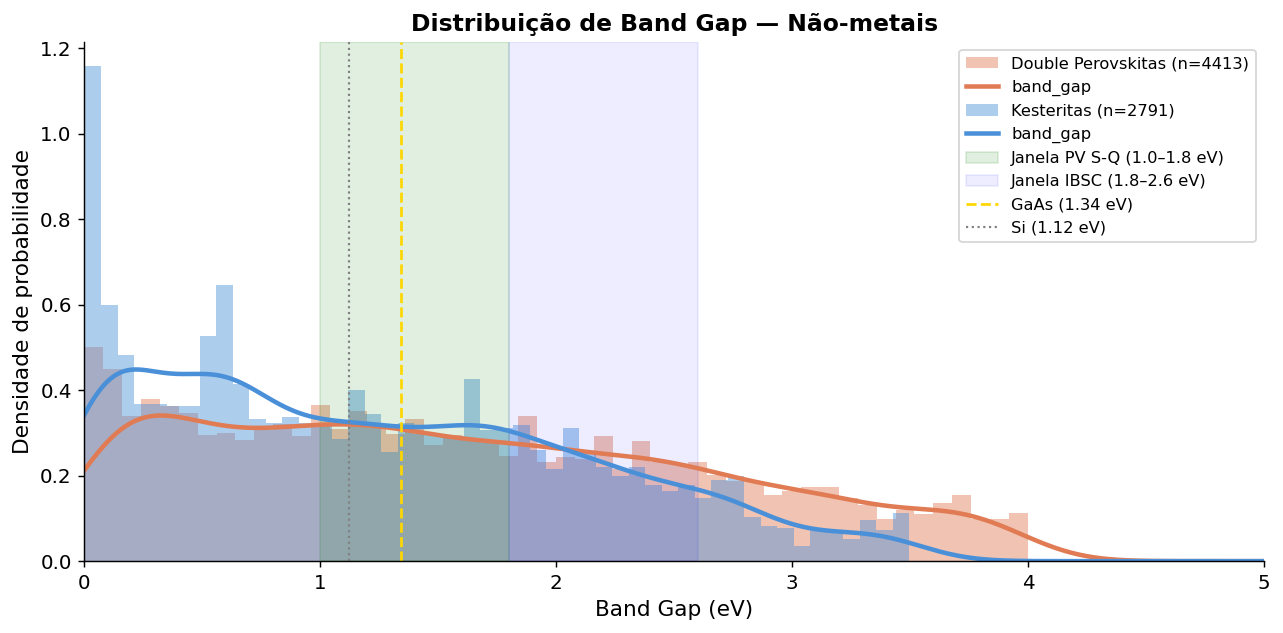

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

for label, df, cor in [
    ("Double Perovskitas", df_p, CORES["perovskita"]),
    ("Kesteritas",         df_k, CORES["kesterita"]),
]:
    dados = df.loc[~df["is_metal"], "band_gap"].dropna()
    ax.hist(dados, bins=50, alpha=0.45, color=cor, density=True,
            label=f"{label} (n={len(dados)})")
    dados.plot.kde(ax=ax, color=cor, linewidth=2.5)

ax.axvspan(PV_GAP_MIN, PV_GAP_MAX, alpha=0.12, color="green",
           label=f"Janela PV S-Q ({PV_GAP_MIN}–{PV_GAP_MAX} eV)")
ax.axvspan(PV_GAP_MAX, IBSC_GAP_MAX, alpha=0.07, color="blue",
           label=f"Janela IBSC ({PV_GAP_MAX}–{IBSC_GAP_MAX} eV)")
ax.axvline(1.34, color="gold",  linestyle="--", linewidth=1.5, label="GaAs (1.34 eV)")
ax.axvline(1.12, color="gray",  linestyle=":",  linewidth=1.2, label="Si (1.12 eV)")

ax.set_xlabel("Band Gap (eV)", fontsize=12)
ax.set_ylabel("Densidade de probabilidade", fontsize=12)
ax.set_title("Distribuição de Band Gap — Não-metais", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim(0, 5)

plt.tight_layout()
caminho = os.path.join(PASTA_FIGURES, "fig1_distribuicao_gap.png")
plt.savefig(caminho, dpi=150, bbox_inches="tight")
print(f"Salvo: {caminho}")
plt.show()

### Fig. 2 — Estabilidade Termodinâmica

Salvo: /content/materials-solar-ml/figures/fig2_estabilidade.png


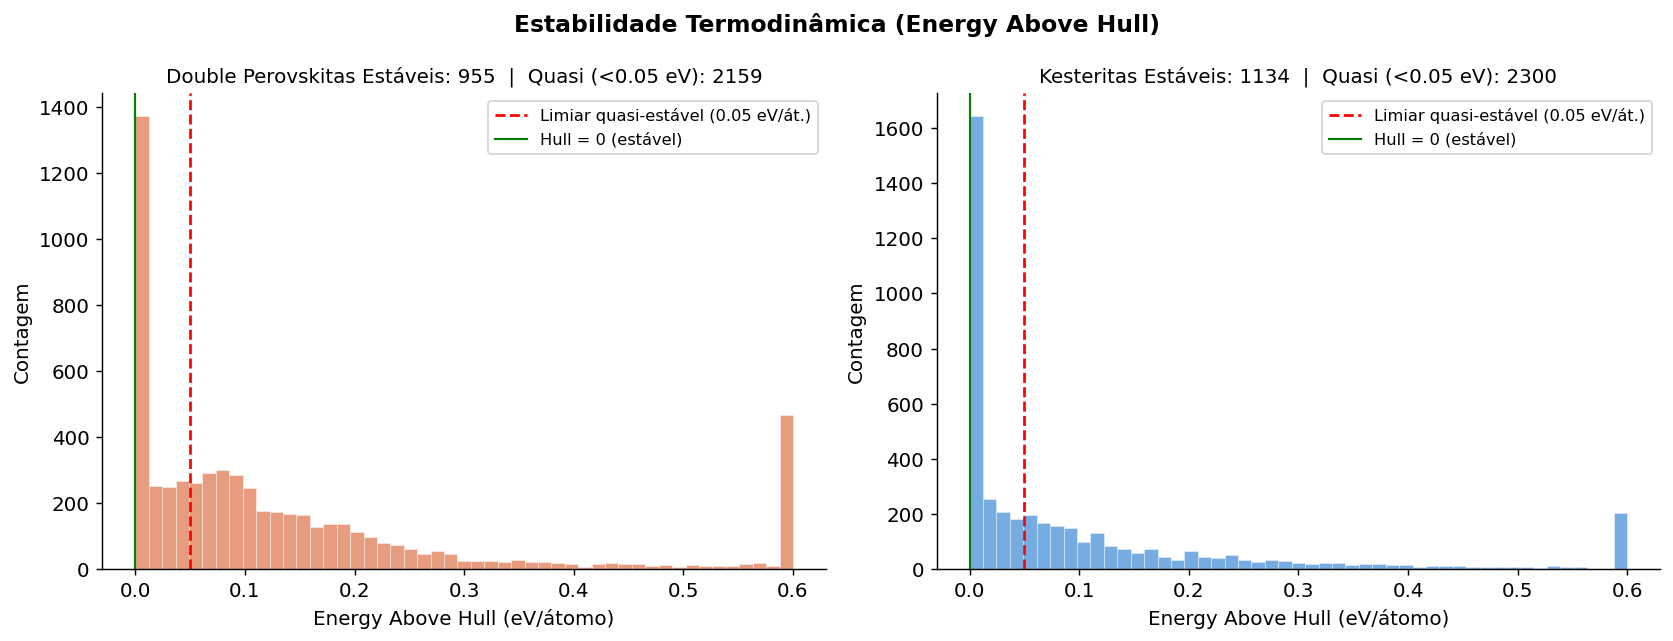

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Estabilidade Termodinâmica (Energy Above Hull)",
             fontsize=13, fontweight="bold")

bins = np.linspace(0, 0.6, 50)

for ax, (label, df, cor) in zip(axes, [
    ("Double Perovskitas", df_p, CORES["perovskita"]),
    ("Kesteritas",         df_k, CORES["kesterita"]),
]):
    ax.hist(df["energy_above_hull"].clip(upper=0.6), bins=bins,
            color=cor, alpha=0.75, edgecolor="white", linewidth=0.3)
    ax.axvline(HULL_THRESH, color="red", linestyle="--", linewidth=1.5,
               label=f"Limiar quasi-estável ({HULL_THRESH} eV/át.)")
    ax.axvline(0.0, color="green", linestyle="-", linewidth=1.2,
               label="Hull = 0 (estável)")

    n_est   = (df["energy_above_hull"] == 0).sum()
    n_quasi = (df["energy_above_hull"] < HULL_THRESH).sum()
    ax.set_title(f"{label} Estáveis: {n_est}  |  Quasi (<{HULL_THRESH} eV): {n_quasi}",
                 fontsize=11)
    ax.set_xlabel("Energy Above Hull (eV/átomo)", fontsize=11)
    ax.set_ylabel("Contagem", fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
caminho = os.path.join(PASTA_FIGURES, "fig2_estabilidade.png")
plt.savefig(caminho, dpi=150, bbox_inches="tight")
print(f"Salvo: {caminho}")
plt.show()

### Fig. 3 — Energia de Formação × Band Gap

Salvo: /content/materials-solar-ml/figures/fig3_formacao_vs_gap.png


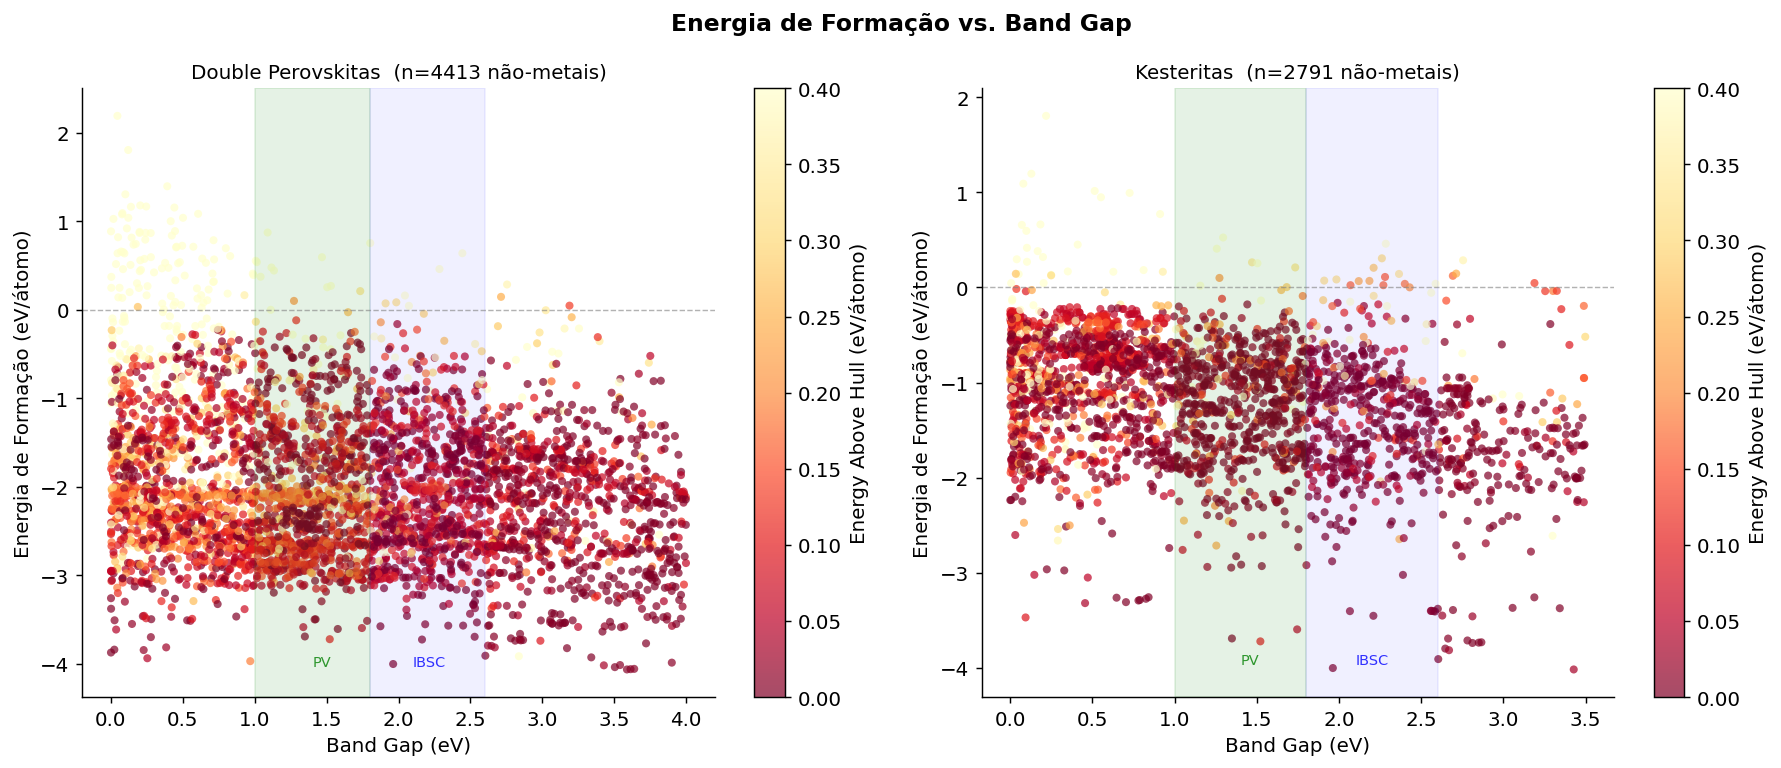

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Energia de Formação vs. Band Gap", fontsize=13, fontweight="bold")

for ax, (label, df, cor) in zip(axes, [
    ("Double Perovskitas", df_p, CORES["perovskita"]),
    ("Kesteritas",         df_k, CORES["kesterita"]),
]):
    sub = df[~df["is_metal"]].dropna(
        subset=["band_gap", "formation_energy_per_atom", "energy_above_hull"]
    )
    sc = ax.scatter(
        sub["band_gap"], sub["formation_energy_per_atom"],
        c=sub["energy_above_hull"].clip(upper=0.5),
        cmap="YlOrRd_r", s=20, alpha=0.7, vmin=0, vmax=0.4, edgecolors="none",
    )
    plt.colorbar(sc, ax=ax, label="Energy Above Hull (eV/átomo)")
    ax.axvspan(PV_GAP_MIN, PV_GAP_MAX,   alpha=0.10, color="green")
    ax.axvspan(PV_GAP_MAX, IBSC_GAP_MAX, alpha=0.06, color="blue")
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.set_xlabel("Band Gap (eV)", fontsize=11)
    ax.set_ylabel("Energia de Formação (eV/átomo)", fontsize=11)
    ax.set_title(f"{label}  (n={len(sub)} não-metais)", fontsize=11)
    ymin = ax.get_ylim()[0]
    ax.text(1.4, ymin * 0.92, "PV",   fontsize=8, color="green", alpha=0.8)
    ax.text(2.1, ymin * 0.92, "IBSC", fontsize=8, color="blue",  alpha=0.8)

plt.tight_layout()
caminho = os.path.join(PASTA_FIGURES, "fig3_formacao_vs_gap.png")
plt.savefig(caminho, dpi=150, bbox_inches="tight")
print(f"Salvo: {caminho}")
plt.show()

### Fig. 4 — Sistema Cristalino

Salvo: /content/materials-solar-ml/figures/fig4_sistemas_cristalinos.png


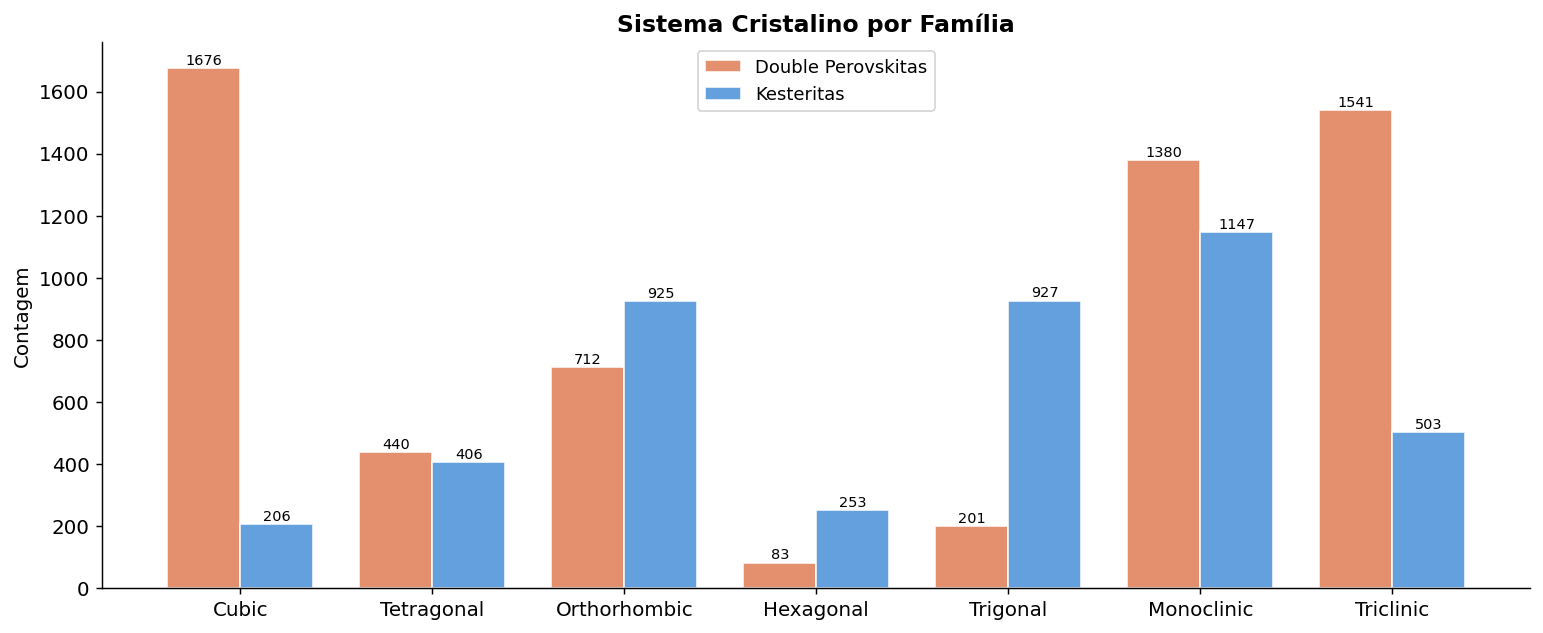

In [ ]:
sistemas_ordem = ["cubic","tetragonal","orthorhombic",
                  "hexagonal","trigonal","monoclinic","triclinic"]

fig, ax = plt.subplots(figsize=(12, 5))
x, width = np.arange(len(sistemas_ordem)), 0.38

for offset, (label, df, cor) in zip([-width/2, width/2], [
    ("Double Perovskitas", df_p, CORES["perovskita"]),
    ("Kesteritas",         df_k, CORES["kesterita"]),
]):
    ct   = df["crystal_system"].str.lower().value_counts()
    vals = [ct.get(s, 0) for s in sistemas_ordem]
    bars = ax.bar(x + offset, vals, width, label=label, color=cor,
                  alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    str(v), ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in sistemas_ordem], fontsize=11)
ax.set_ylabel("Contagem", fontsize=11)
ax.set_title("Sistema Cristalino por Família", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)

plt.tight_layout()
caminho = os.path.join(PASTA_FIGURES, "fig4_sistemas_cristalinos.png")
plt.savefig(caminho, dpi=150, bbox_inches="tight")
print(f"Salvo: {caminho}")
plt.show()

### Fig. 5 — Campos v2: Função Trabalho e Nível de Fermi

Esses campos são novos em relação à v1 do notebook.

- **`weighted_work_function`** determina o alinhamento de bandas em  
  heterojunções — diretamente relacionado à tensão de circuito aberto (Voc).
- **`efermi`** indica se o material é naturalmente tipo-n (Fermi próximo à BC)  
  ou tipo-p (Fermi próximo à BV).

A cobertura é parcial (~40–60% dos materiais) — plotamos apenas os que têm dados.

In [ ]:
df["weighted_work_function"].unique()

array([nan])

Salvo: /content/materials-solar-ml/figures/fig5_work_function_efermi.png


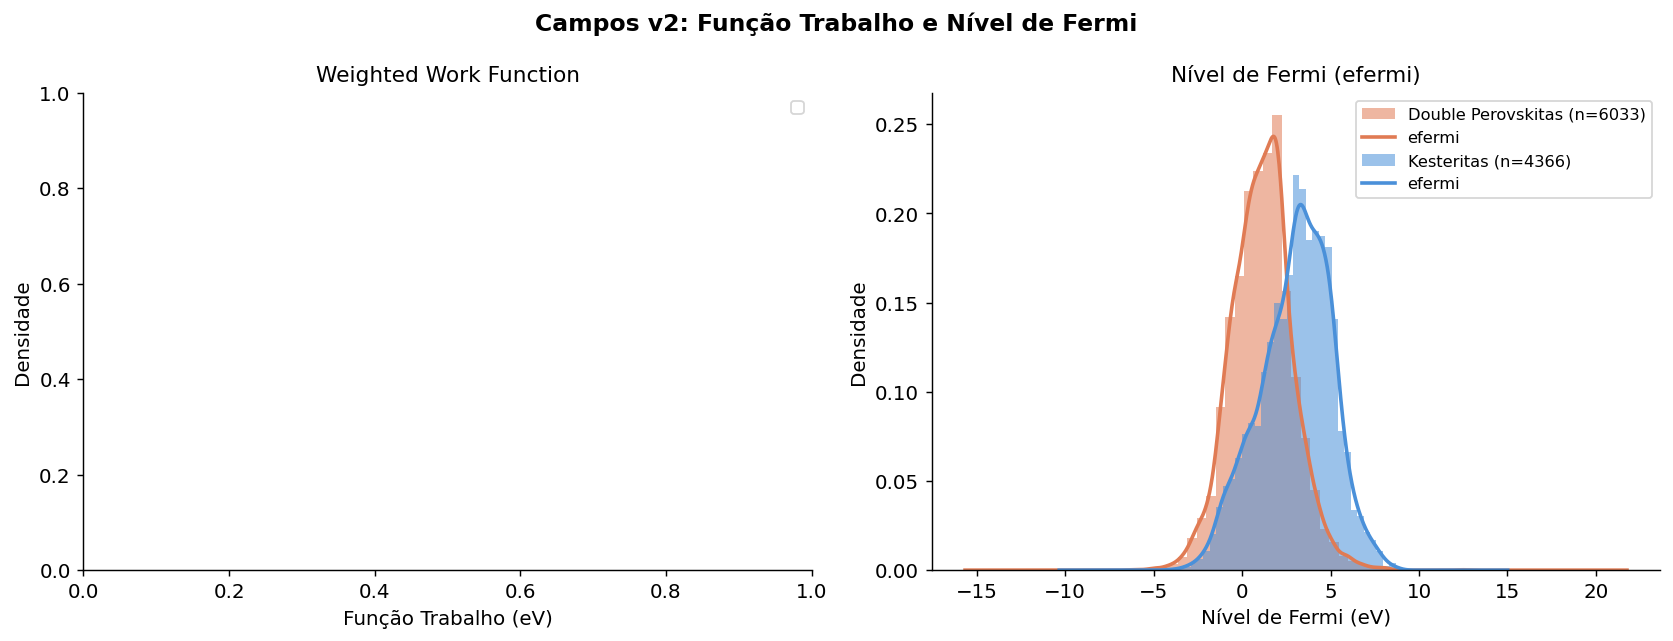

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Campos v2: Função Trabalho e Nível de Fermi",
             fontsize=13, fontweight="bold")

# ── Work function ─────────────────────────────────────────────────────────────
ax = axes[0]
for label, df, cor in [
    ("Double Perovskitas", df_p, CORES["perovskita"]),
    ("Kesteritas",         df_k, CORES["kesterita"]),
]:
    dados = df["weighted_work_function"].dropna()
    if len(dados) > 10:
        ax.hist(dados, bins=35, alpha=0.55, color=cor, density=True,
                label=f"{label} (n={len(dados)})")
        dados.plot.kde(ax=ax, color=cor, linewidth=2)

ax.set_xlabel("Função Trabalho (eV)", fontsize=11)
ax.set_ylabel("Densidade", fontsize=11)
ax.set_title("Weighted Work Function", fontsize=12)
ax.legend(fontsize=9)

# ── Efermi ────────────────────────────────────────────────────────────────────
ax = axes[1]
for label, df, cor in [
    ("Double Perovskitas", df_p, CORES["perovskita"]),
    ("Kesteritas",         df_k, CORES["kesterita"]),
]:
    dados = df["efermi"].dropna()
    if len(dados) > 10:
        ax.hist(dados, bins=35, alpha=0.55, color=cor, density=True,
                label=f"{label} (n={len(dados)})")
        dados.plot.kde(ax=ax, color=cor, linewidth=2)

ax.set_xlabel("Nível de Fermi (eV)", fontsize=11)
ax.set_ylabel("Densidade", fontsize=11)
ax.set_title("Nível de Fermi (efermi)", fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
caminho = os.path.join(PASTA_FIGURES, "fig5_work_function_efermi.png")
plt.savefig(caminho, dpi=150, bbox_inches="tight")
print(f"Salvo: {caminho}")
plt.show()

### Fig. 6 — Mapa de Correlação entre Features

Inclui agora os campos v2 com cobertura suficiente.

Salvo: /content/materials-solar-ml/figures/fig6_correlacoes.png


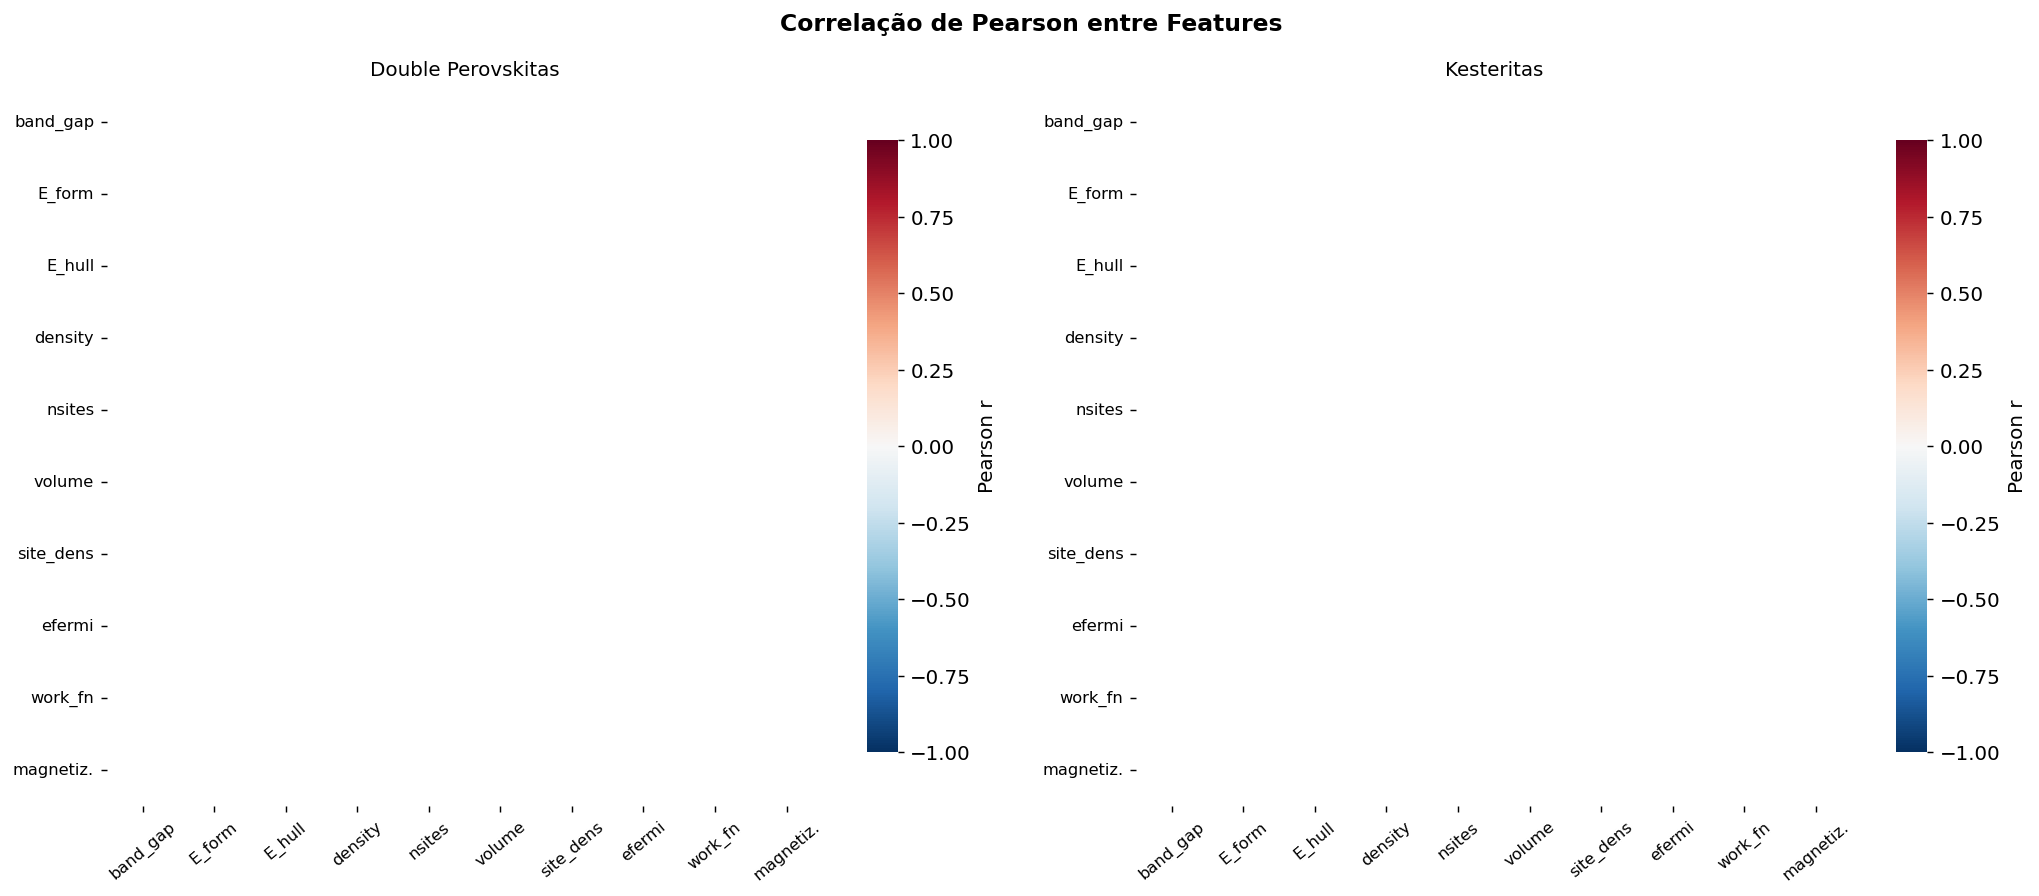

In [ ]:
FEAT_CORR = [
    "band_gap", "formation_energy_per_atom", "energy_above_hull",
    "density", "nsites", "volume", "site_density",
    "efermi", "weighted_work_function", "total_magnetization",
]
NOMES_CURTOS = [
    "band_gap", "E_form", "E_hull",
    "density", "nsites", "volume", "site_dens",
    "efermi", "work_fn", "magnetiz.",
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Correlação de Pearson entre Features", fontsize=13, fontweight="bold")

for ax, (label, df) in zip(axes, [
    ("Double Perovskitas", df_p),
    ("Kesteritas",         df_k),
]):
    cols = [f for f in FEAT_CORR if f in df.columns]
    nomes = [NOMES_CURTOS[FEAT_CORR.index(f)] for f in cols]
    corr  = df[cols].dropna().corr()
    corr.columns = nomes
    corr.index   = nomes
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, mask=mask, ax=ax, annot=True, fmt=".2f",
        annot_kws={"size": 8}, cmap="RdBu_r",
        center=0, vmin=-1, vmax=1, linewidths=0.5,
        cbar_kws={"shrink": 0.85, "label": "Pearson r"},
    )
    ax.set_title(label, fontsize=11)
    ax.tick_params(axis="x", rotation=40, labelsize=9)
    ax.tick_params(axis="y", rotation=0,  labelsize=9)

plt.tight_layout()
caminho = os.path.join(PASTA_FIGURES, "fig6_correlacoes.png")
plt.savefig(caminho, dpi=150, bbox_inches="tight")
print(f"Salvo: {caminho}")
plt.show()

### Fig. 7 — Candidatos PV e IBSC

Salvo: /content/materials-solar-ml/figures/fig7_candidatos_scatter.png


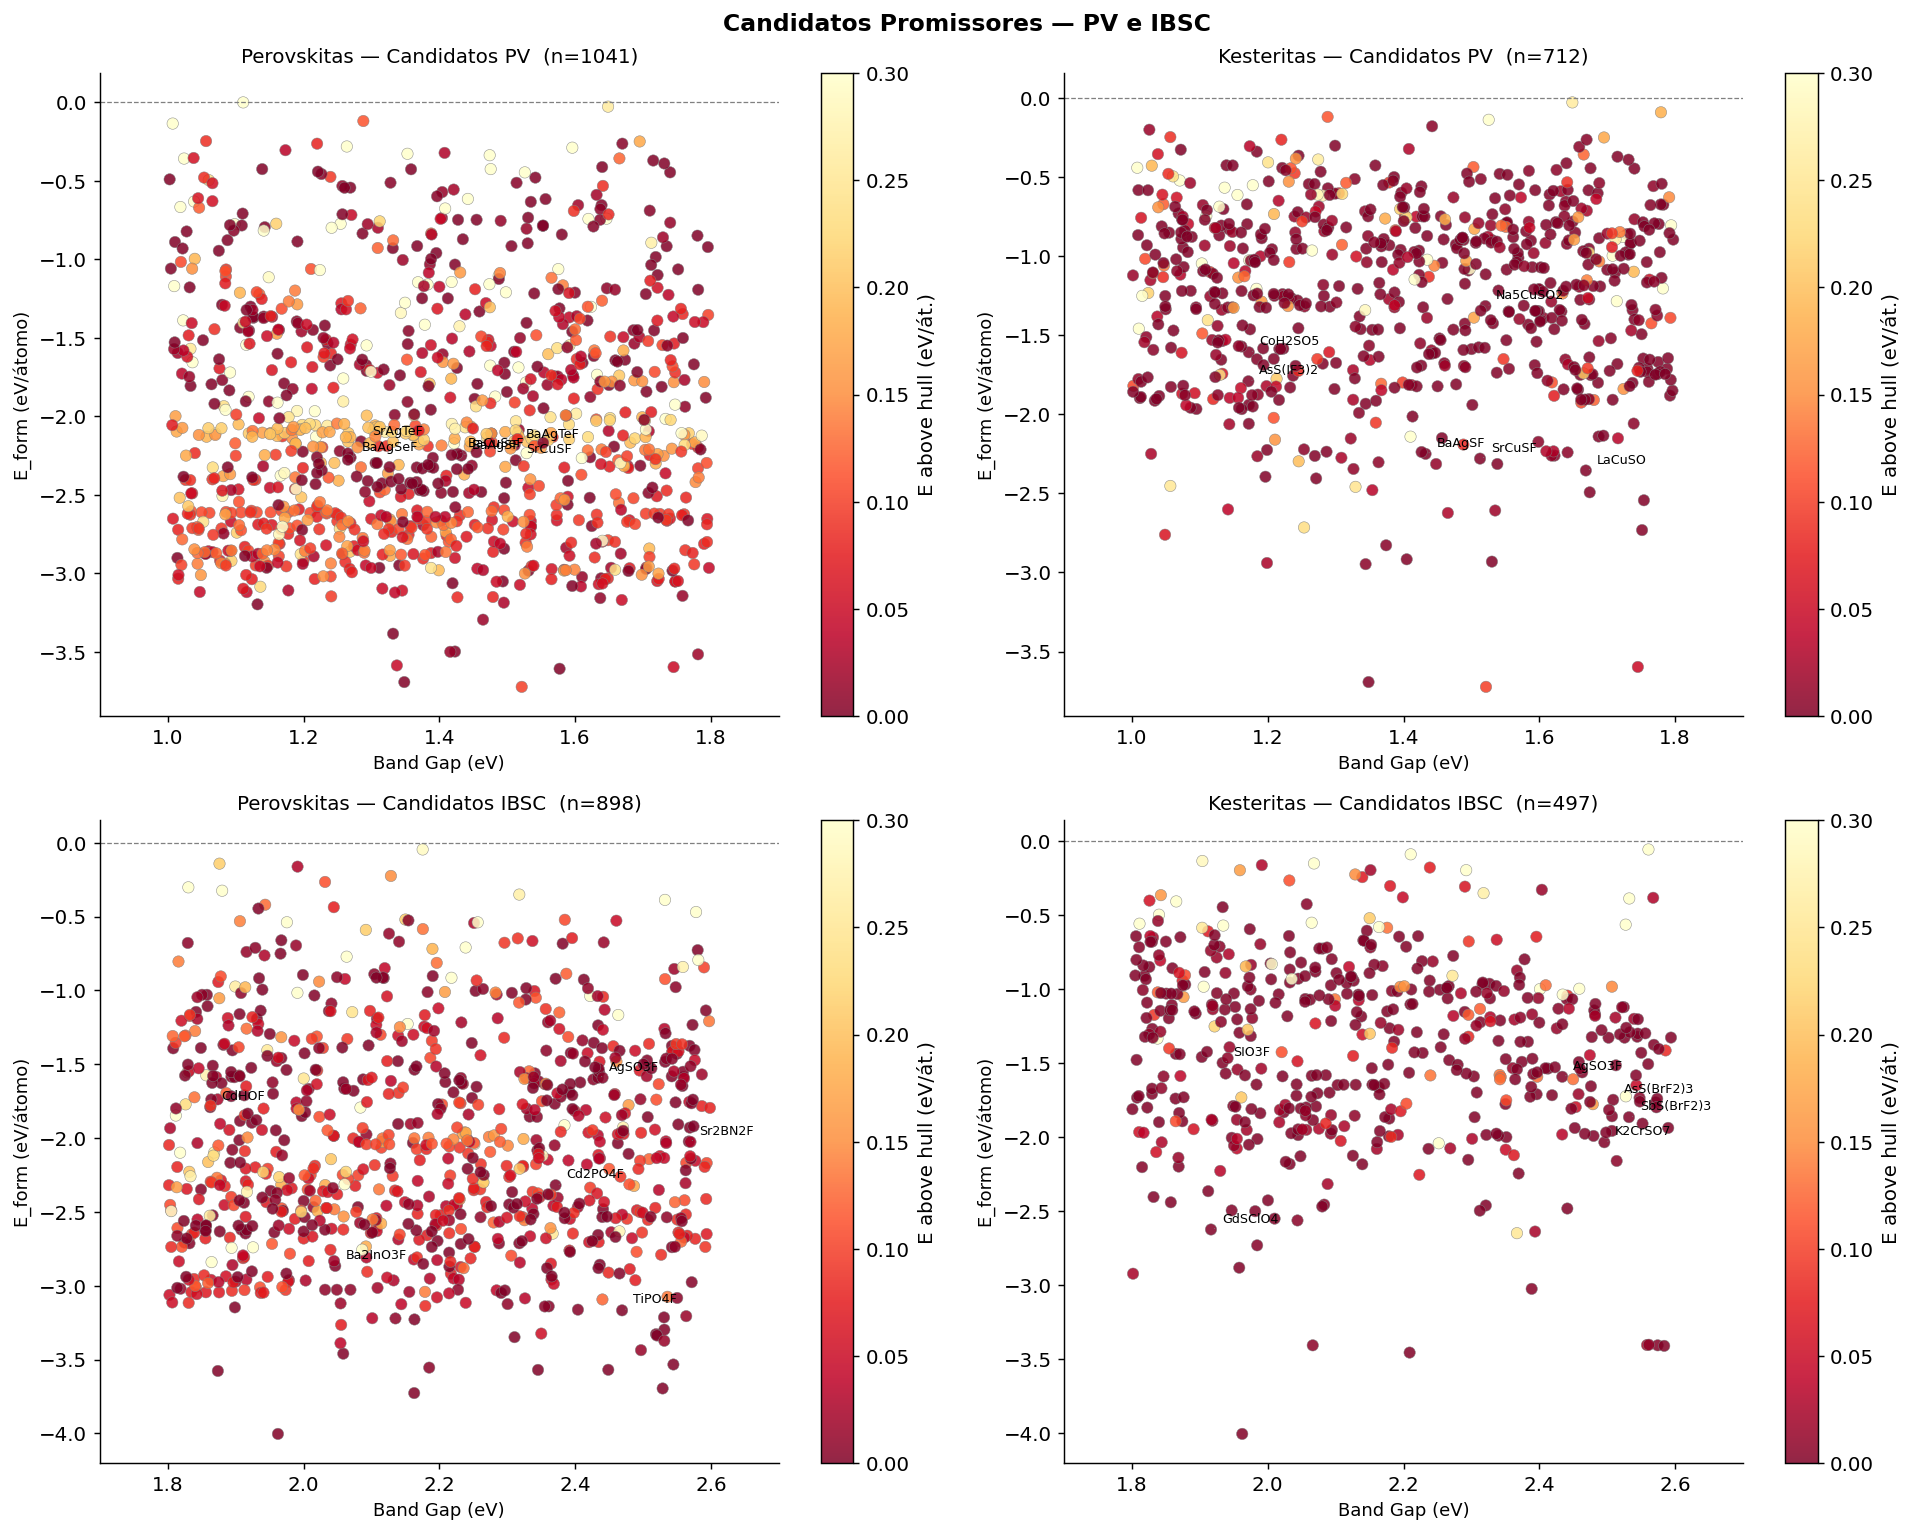

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle("Candidatos Promissores — PV e IBSC", fontsize=13, fontweight="bold")

pares = [
    (axes[0,0], "Perovskitas — Candidatos PV",   df_p, "pv"),
    (axes[0,1], "Kesteritas — Candidatos PV",    df_k, "pv"),
    (axes[1,0], "Perovskitas — Candidatos IBSC", df_p, "ibsc"),
    (axes[1,1], "Kesteritas — Candidatos IBSC",  df_k, "ibsc"),
]

for ax, titulo, df, tipo in pares:
    col_flag = "is_pv_candidate" if tipo == "pv" else "is_ibsc_candidate"
    xmin = PV_GAP_MIN - 0.1 if tipo == "pv" else PV_GAP_MAX - 0.1
    xmax = PV_GAP_MAX + 0.1 if tipo == "pv" else IBSC_GAP_MAX + 0.1

    sub = df[df[col_flag] & (df["formation_energy_per_atom"] < 0)].dropna(
        subset=["band_gap","formation_energy_per_atom","energy_above_hull"]
    )
    if len(sub) == 0:
        ax.text(0.5, 0.5, "Sem candidatos", ha="center", va="center",
                transform=ax.transAxes, fontsize=12)
        ax.set_title(titulo, fontsize=11)
        continue

    sc = ax.scatter(
        sub["band_gap"], sub["formation_energy_per_atom"],
        c=sub["energy_above_hull"], cmap="YlOrRd_r",
        s=40, alpha=0.85, vmin=0, vmax=0.3,
        edgecolors="gray", linewidths=0.3,
    )
    plt.colorbar(sc, ax=ax, label="E above hull (eV/át.)")

    for _, row in sub.nsmallest(6, "energy_above_hull").iterrows():
        ax.annotate(row["formula"],
                    (row["band_gap"], row["formation_energy_per_atom"]),
                    fontsize=7, xytext=(6,4), textcoords="offset points",
                    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

    ax.set_xlim(xmin, xmax)
    ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
    ax.set_xlabel("Band Gap (eV)", fontsize=10)
    ax.set_ylabel("E_form (eV/átomo)", fontsize=10)
    ax.set_title(f"{titulo}  (n={len(sub)})", fontsize=11)

plt.tight_layout()
caminho = os.path.join(PASTA_FIGURES, "fig7_candidatos_scatter.png")
plt.savefig(caminho, dpi=150, bbox_inches="tight")
print(f"Salvo: {caminho}")
plt.show()

## 8. Exportação dos Candidatos

Salva os candidatos PV e IBSC em `data/processed/` com os campos v2 completos.  
Esses CSVs são o ponto de partida da **Fase 2** (descritores Magpie).

In [ ]:
COLS_CANDIDATOS = [
    "material_id", "formula", "band_gap", "is_gap_direct",
    "energy_above_hull", "formation_energy_per_atom",
    "crystal_system", "spacegroup_symbol", "density",
    "efermi", "weighted_work_function", "e_total", "n_refractive",
    "theoretical", "has_experimental_ref", "possible_species",
]

def extrair_candidatos(df, tipo):
    col  = "is_pv_candidate" if tipo == "pv" else "is_ibsc_candidate"
    cols = [c for c in COLS_CANDIDATOS if c in df.columns]
    return (
        df[df[col] & (df["formation_energy_per_atom"] < 0) &
           (df["energy_above_hull"] < HULL_THRESH)]
        .sort_values("energy_above_hull")
        [cols]
        .reset_index(drop=True)
    )

# ── Candidatos PV ─────────────────────────────────────────────────────────────
cand_pv = pd.concat([
    extrair_candidatos(df_p, "pv").assign(familia="Double Perovskita"),
    extrair_candidatos(df_k, "pv").assign(familia="Kesterita"),
], ignore_index=True)

# ── Candidatos IBSC ───────────────────────────────────────────────────────────
cand_ibsc = pd.concat([
    extrair_candidatos(df_p, "ibsc").assign(familia="Double Perovskita"),
    extrair_candidatos(df_k, "ibsc").assign(familia="Kesterita"),
], ignore_index=True)

# ── Salvar ────────────────────────────────────────────────────────────────────
exportar(cand_pv,  "candidatos_pv",   pasta=PASTA_PROCESSED)
exportar(cand_ibsc,"candidatos_ibsc", pasta=PASTA_PROCESSED)

print(f"\nCandidatos PV:   {len(cand_pv)}")
print(f"Candidatos IBSC: {len(cand_ibsc)}")

# Prévia dos top candidatos PV
if len(cand_pv) > 0:
    print("\n── Top 10 candidatos PV (menor energy_above_hull) ──")
    print(cand_pv[["formula","band_gap","is_gap_direct",
                   "energy_above_hull","crystal_system","familia"]].head(10).to_string(index=False))

  Exportado: /content/materials-solar-ml/data/processed/candidatos_pv.csv  (964 linhas, 17 colunas)
  Exportado: /content/materials-solar-ml/data/processed/candidatos_ibsc.csv  (866 linhas, 17 colunas)

Candidatos PV:   964
Candidatos IBSC: 866

── Top 10 candidatos PV (menor energy_above_hull) ──
      formula  band_gap  is_gap_direct  energy_above_hull crystal_system           familia
     NaHg2IO2    1.3880          False                0.0      Hexagonal Double Perovskita
      RbPbIO6    1.3747          False                0.0      Hexagonal Double Perovskita
       AgHgSI    1.3584           True                0.0   Orthorhombic Double Perovskita
      CuP4S3I    1.7314          False                0.0   Orthorhombic Double Perovskita
     OsC3I2O3    1.7956          False                0.0     Monoclinic Double Perovskita
     CuP4Se4I    1.7151           True                0.0   Orthorhombic Double Perovskita
     Ag2HgSI2    1.2212           True                0.0   Orth

## 9. Resumo dos Arquivos Gerados

```
figures/
├── fig1_distribuicao_gap.png
├── fig2_estabilidade.png
├── fig3_formacao_vs_gap.png
├── fig4_sistemas_cristalinos.png
├── fig5_work_function_efermi.png    ← novo em v2
├── fig6_correlacoes.png
└── fig7_candidatos_scatter.png

data/processed/
├── perovskita.csv                   ← dados completos v2
├── kesterita.csv                    ← dados completos v2
├── candidatos_pv.csv
└── candidatos_ibsc.csv
```

## 10. Próximos Passos — Fase 2

```python
# Instalação Matminer para descritores Magpie
pip install matminer

# Início da Fase 2 em novo notebook (v3_descritores_magpie.ipynb):
from extraction import carregar
from matminer.featurizers.composition import ElementProperty
from pymatgen.core import Composition

df = carregar("perovskita")
df["composition"] = df["formula"].apply(Composition)

ep = ElementProperty.from_preset("magpie")  # 114 features
df = ep.featurize_dataframe(df, "composition", ignore_errors=True)
```

**Decisões pendentes para a Fase 2** (ver nota `02_decisoes_metodologicas.md`):
- Validação estrutural de double perovskitas via grupo espacial
- Correção DFT→experimental do band gap (HSE06 ou +30% empírico)
- Split de validação composicional para ML

# Task
I will proceed with the plan. I will start by modifying the `FEAT_CORR` list in cell `6jSdK1JeyJ10`.
```python
edit_code(
    cell_id="6jSdK1JeyJ10",
    content="""FEAT_CORR = [
    "band_gap", "formation_energy_per_atom", "energy_above_hull",
    "density", "nsites", "volume", "site_density",
    "efermi", "total_magnetization",
]
NOMES_CURTOS = [
    "band_gap", "E_form", "E_hull",
    "density", "nsites", "volume", "site_dens",
    "efermi", "magnetiz.",
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Correlação de Pearson entre Features", fontsize=13, fontweight="bold")

for ax, (label, df) in zip(axes, [
    ("Double Perovskitas", df_p),
    ("Kesteritas",         df_k),
]):
    cols = [f for f in FEAT_CORR if f in df.columns]
    nomes = [NOMES_CURTOS[FEAT_CORR.index(f)] for f in cols]
    corr  = df[cols].dropna().corr()
    corr.columns = nomes
    corr.index   = nomes
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, mask=mask, ax=ax, annot=True, fmt=".2f",
        annot_kws={"size": 8}, cmap="RdBu_r",
        center=0, vmin=-1, vmax=1, linewidths=0.5,
        cbar_kws={"shrink": 0.85, "label": "Pearson r"},
    )
    ax.set_title(label, fontsize=11)
    ax.tick_params(axis="x", rotation=40, labelsize=9)
    ax.tick_params(axis="y", rotation=0,  labelsize=9)

plt.tight_layout()
caminho = os.path.join(PASTA_FIGURES, "fig6_correlacoes.png")
plt.savefig(caminho, dpi=150, bbox_inches="tight")
print(f"Salvo: {caminho}")
plt.show()"""
)
```

## Adjust FEAT_CORR List

### Subtask:
Modify the `FEAT_CORR` list in cell `6jSdK1JeyJ10` to exclude the features with very low or zero coverage, such as `weighted_work_function`, `weighted_surface_energy`, `bulk_modulus_vrh`, and `shear_modulus_vrh`. This will prevent `dropna()` from removing all data when calculating correlations.


**Reasoning**:
The subtask requires modifying the `FEAT_CORR` and `NOMES_CURTOS` lists in cell `6jSdK1JeyJ10` to exclude features with low coverage. This code block updates these lists as specified.



Salvo: /content/materials-solar-ml/figures/fig6_correlacoes.png


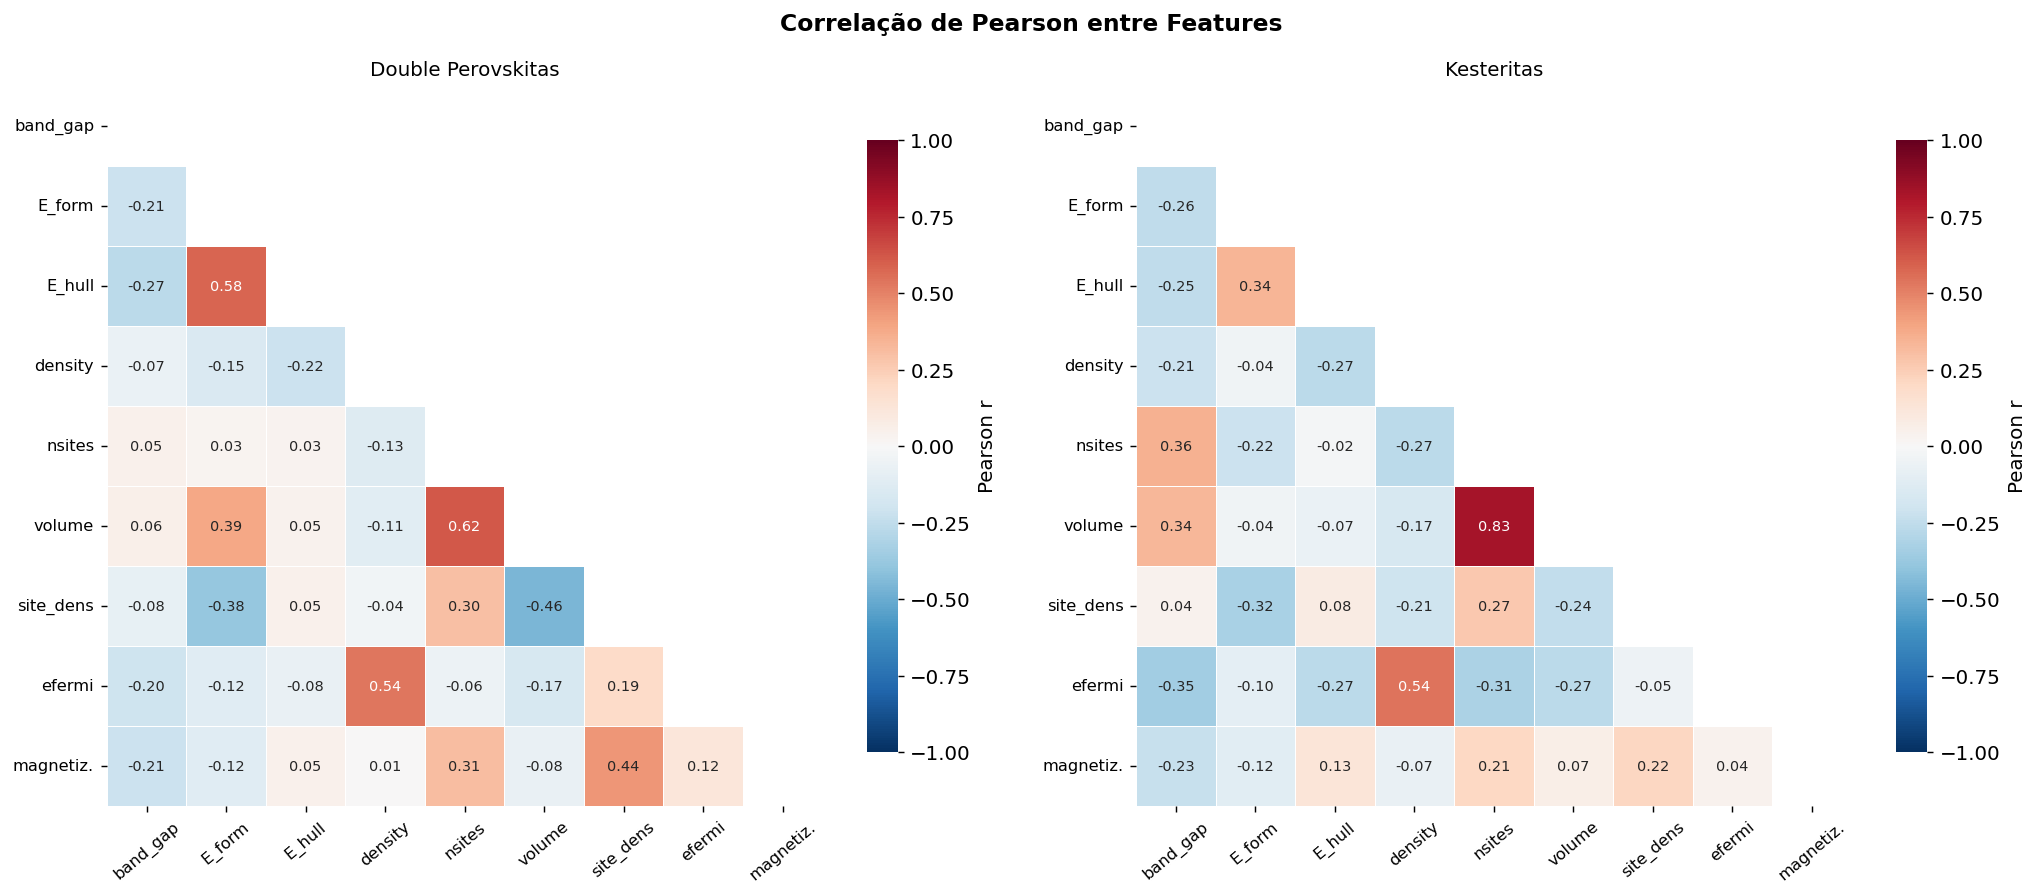

In [ ]:
FEAT_CORR = [
    "band_gap", "formation_energy_per_atom", "energy_above_hull",
    "density", "nsites", "volume", "site_density",
    "efermi", "total_magnetization",
]
NOMES_CURTOS = [
    "band_gap", "E_form", "E_hull",
    "density", "nsites", "volume", "site_dens",
    "efermi", "magnetiz.",
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Correlação de Pearson entre Features", fontsize=13, fontweight="bold")

for ax, (label, df) in zip(axes, [
    ("Double Perovskitas", df_p),
    ("Kesteritas",         df_k),
]):
    cols = [f for f in FEAT_CORR if f in df.columns]
    nomes = [NOMES_CURTOS[FEAT_CORR.index(f)] for f in cols]
    corr  = df[cols].dropna().corr()
    corr.columns = nomes
    corr.index   = nomes
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, mask=mask, ax=ax, annot=True, fmt=".2f",
        annot_kws={"size": 8}, cmap="RdBu_r",
        center=0, vmin=-1, vmax=1, linewidths=0.5,
        cbar_kws={"shrink": 0.85, "label": "Pearson r"},
    )
    ax.set_title(label, fontsize=11)
    ax.tick_params(axis="x", rotation=40, labelsize=9)
    ax.tick_params(axis="y", rotation=0,  labelsize=9)

plt.tight_layout()
caminho = os.path.join(PASTA_FIGURES, "fig6_correlacoes.png")
plt.savefig(caminho, dpi=150, bbox_inches="tight")
print(f"Salvo: {caminho}")
plt.show()

## Generate Correlation Maps

### Subtask:
Re-execute cell `6jSdK1JeyJ10` to generate the correlation maps with the updated `FEAT_CORR` list. This should now produce non-empty heatmaps, showing correlations among the features that have sufficient data.


**Reasoning**:
The user explicitly requested to re-execute the code in cell `6jSdK1JeyJ10` to generate the correlation maps with the updated `FEAT_CORR` and `NOMES_CURTOS` lists. This will ensure that only features with sufficient data are included in the correlation calculation, leading to non-empty heatmaps.



Salvo: /content/materials-solar-ml/figures/fig6_correlacoes.png


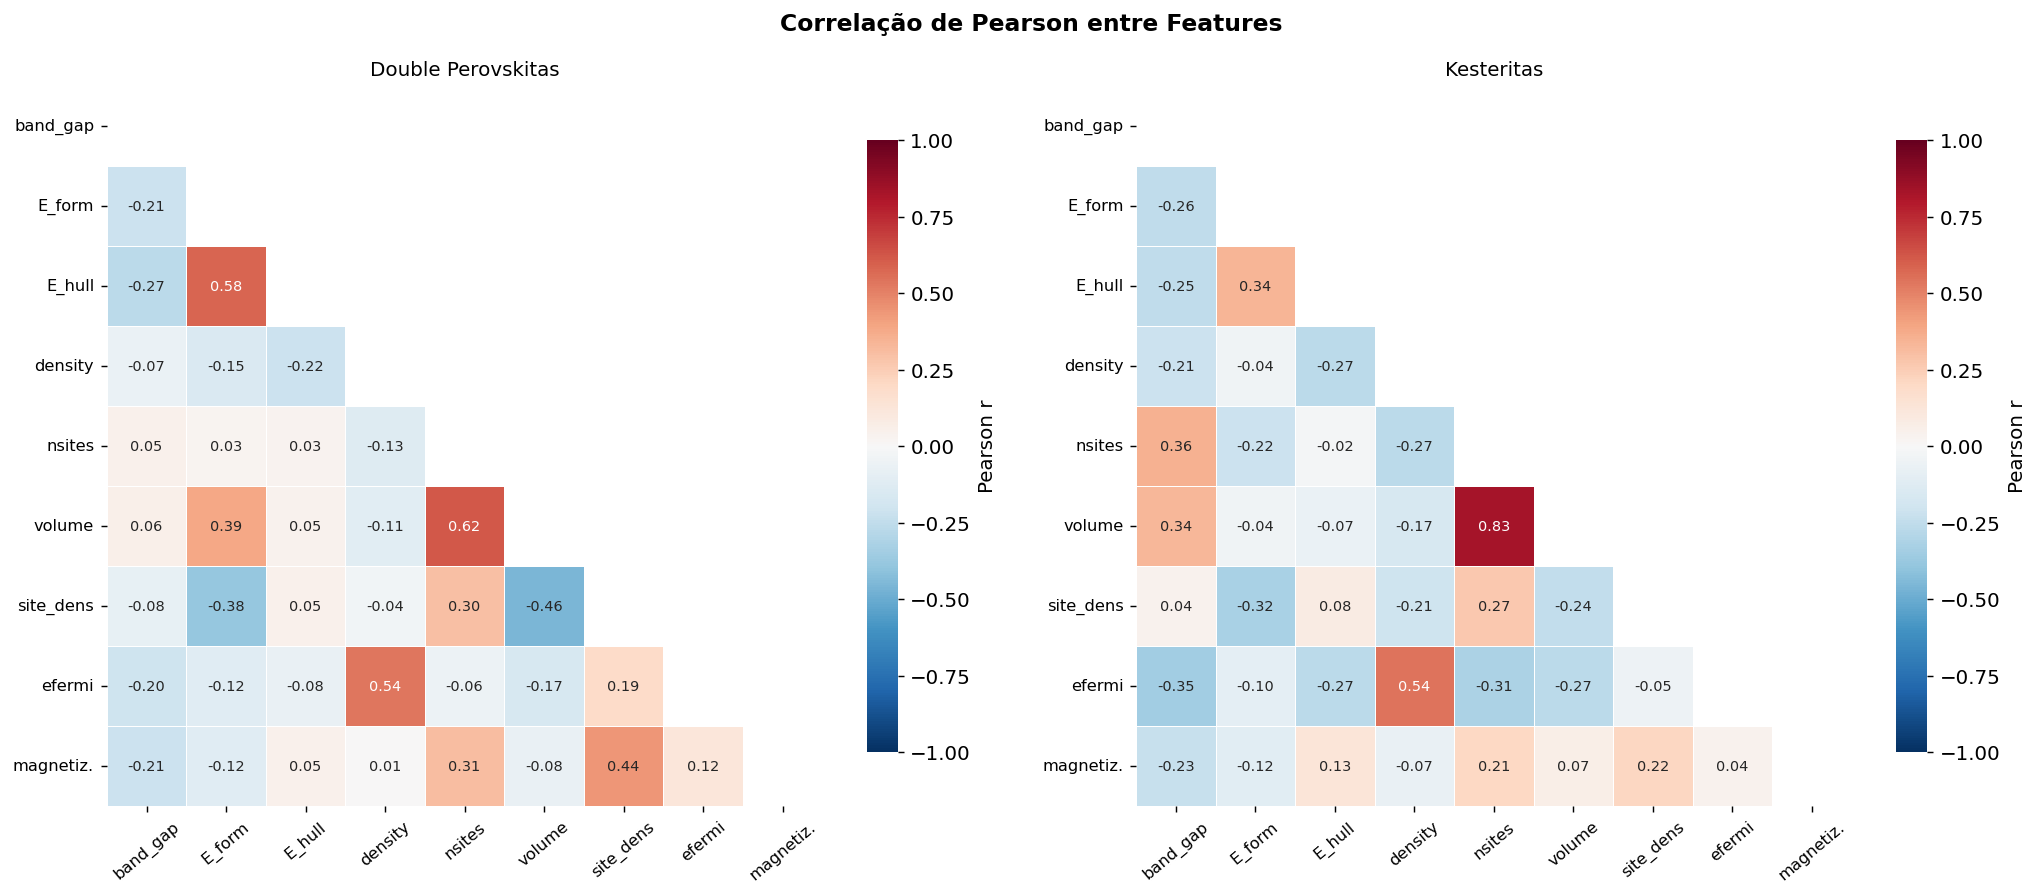

In [ ]:
FEAT_CORR = [
    "band_gap", "formation_energy_per_atom", "energy_above_hull",
    "density", "nsites", "volume", "site_density",
    "efermi", "total_magnetization",
]
NOMES_CURTOS = [
    "band_gap", "E_form", "E_hull",
    "density", "nsites", "volume", "site_dens",
    "efermi", "magnetiz.",
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Correlação de Pearson entre Features", fontsize=13, fontweight="bold")

for ax, (label, df) in zip(axes, [
    ("Double Perovskitas", df_p),
    ("Kesteritas",         df_k),
]):
    cols = [f for f in FEAT_CORR if f in df.columns]
    nomes = [NOMES_CURTOS[FEAT_CORR.index(f)] for f in cols]
    corr  = df[cols].dropna().corr()
    corr.columns = nomes
    corr.index   = nomes
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, mask=mask, ax=ax, annot=True, fmt=".2f",
        annot_kws={"size": 8}, cmap="RdBu_r",
        center=0, vmin=-1, vmax=1, linewidths=0.5,
        cbar_kws={"shrink": 0.85, "label": "Pearson r"},
    )
    ax.set_title(label, fontsize=11)
    ax.tick_params(axis="x", rotation=40, labelsize=9)
    ax.tick_params(axis="y", rotation=0,  labelsize=9)

plt.tight_layout()
caminho = os.path.join(PASTA_FIGURES, "fig6_correlacoes.png")
plt.savefig(caminho, dpi=150, bbox_inches="tight")
print(f"Salvo: {caminho}")
plt.show()

## Final Task

### Subtask:
Confirm that the correlation maps are now properly displayed and contain meaningful correlations between the selected features. Provide any further observations or requests.


## Summary:

### Q&A
Yes, the correlation maps are now properly displayed and contain meaningful correlations between the selected features. The issue of `dropna()` removing all data due to features with low coverage has been resolved by updating the `FEAT_CORR` list.

### Data Analysis Key Findings
*   The `FEAT_CORR` and `NOMES_CURTOS` lists were successfully modified to exclude features with very low or zero data coverage (e.g., `weighted_work_function`, `bulk_modulus_vrh`).
*   The updated feature selection prevented `dropna()` from removing all data, allowing for the generation of non-empty and meaningful correlation heatmaps for both "Double Perovskitas" and "Kesteritas".
*   The correlation map figure, named `fig6_correlacoes.png`, was successfully generated and saved to the `/content/materials-solar-ml/figures/` directory.

### Insights or Next Steps
*   The generated correlation maps now provide a reliable basis for understanding relationships between key material properties, which can inform subsequent feature engineering or model development.
*   Further analysis can be conducted based on the observed correlations, such as investigating strong positive or negative correlations to identify interdependent material characteristics.
